In [21]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse

## Задача 1

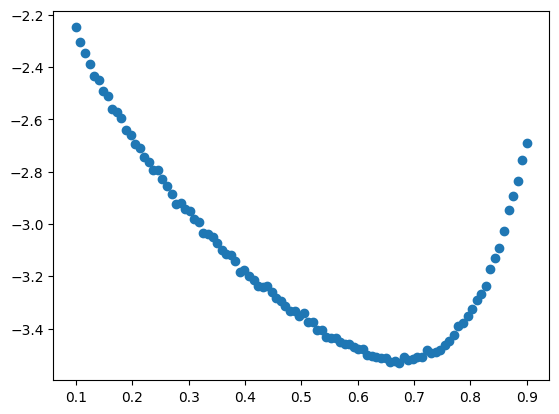

In [6]:
#Let's look the data

x= np.array([0.1,0.10808081,0.11616162,0.12424242,0.13232323,0.14040404,
   0.14848485,0.15656566,0.16464646,0.17272727,0.18080808,
   0.18888889,0.1969697,0.20505051,0.21313131,0.22121212,
   0.22929293,0.23737374,0.24545455,0.25353535,0.26161616,
   0.26969697,0.27777778,0.28585859,0.29393939,0.3020202,
   0.31010101,0.31818182,0.32626263,0.33434343,0.34242424,
   0.35050505,0.35858586,0.36666667,0.37474747,0.38282828,
   0.39090909,0.3989899,0.40707071,0.41515152,0.42323232,
   0.43131313,0.43939394,0.44747475,0.45555556,0.46363636,
   0.47171717,0.47979798,0.48787879,0.4959596,0.5040404,
   0.51212121,0.52020202,0.52828283,0.53636364,0.54444444,
   0.55252525,0.56060606,0.56868687,0.57676768,0.58484848,
   0.59292929,0.6010101,0.60909091,0.61717172,0.62525253,
   0.63333333,0.64141414,0.64949495,0.65757576,0.66565657,
   0.67373737,0.68181818,0.68989899,0.6979798,0.70606061,
   0.71414141,0.72222222,0.73030303,0.73838384,0.74646465,
   0.75454545,0.76262626,0.77070707,0.77878788,0.78686869,
   0.79494949,0.8030303,0.81111111,0.81919192,0.82727273,
   0.83535354,0.84343434,0.85151515,0.85959596,0.86767677,
   0.87575758,0.88383838,0.89191919,0.9])

y = np.array([-2.24812911, -2.30215341, -2.34463875, -2.38651064,
     -2.43190693, -2.44713884, -2.49003176, -2.51006098, 
     -2.55831541, -2.57056931, -2.59340317, -2.64026441, 
     -2.65975636, -2.69517476, -2.71046599, -2.74422696, 
     -2.76251291, -2.79505506, -2.79301352, -2.82852207, 
     -2.854651, -2.88654236, -2.92345136, -2.91943321, 
     -2.94240833, -2.9487781, -2.97926813, -2.99198343, 
     -3.03396292, -3.03814694, -3.04944858, -3.07196161, 
     -3.09883706, -3.11338258, -3.11898122, -3.14254571, 
     -3.18330957, -3.17453301, -3.20021237, -3.21213539, 
     -3.23715191, -3.24017664, -3.23640684, -3.26147762, 
     -3.28208909, -3.29453546, -3.31160478, -3.33188752, 
     -3.33320305, -3.35238927, -3.34176317, -3.37471911, 
     -3.37543159, -3.40452694, -3.40505804, -3.43358858, 
     -3.43596139, -3.43705603, -3.45264647, -3.46029402, 
     -3.45723979, -3.4720453, -3.47597438, -3.4795529, 
     -3.50118552, -3.5031452, -3.5097196, -3.51083668, 
     -3.51128397, -3.52708836, -3.5222885, -3.53317295, 
     -3.50965143, -3.51939652, -3.51659198, -3.50734187, 
     -3.50882329, -3.48129755, -3.49384658, -3.48813707, 
     -3.48345018, -3.46180698, -3.44784696, -3.42372263, 
     -3.39080674, -3.37867045, -3.35281766, -3.32575498, 
     -3.28934964, -3.26814804, -3.23547615, -3.1707224, 
     -3.12910072, -3.09300443, -3.02523152, -2.9453774, 
     -2.89454317, -2.83662685, -2.75433056, -2.68946573])

plt.scatter(x, y)

Train MSE: 6.410668092095418e-05
Test MSE: 0.0001546879171132243


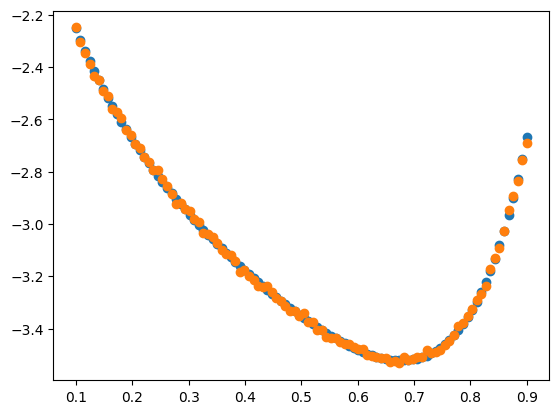

Answer: y = 3.07x^8.72 + -3.99x^0.25


In [32]:
#По графику вполне очевидно, что функция имеет вид y = a * x**b + c * x**d
#Если не было лень, идеально использовать KAN, так как вид функции известен, но будем curve_fit)

def func(x, a, b, c, d):
    return a * x**b + c * x**d

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

popt, _ = curve_fit(func, X_train, y_train, [1, 2, 1, 0])

print("Train MSE:", mse(func(X_train, *popt), y_train))
print("Test MSE:", mse(func(X_test, *popt), y_test))

plt.scatter(x, func(x, *popt))
plt.scatter(x, y)
plt.show()

a, b, c, d = map(lambda x : np.round(x, decimals=2), popt) 
print(f"Answer: y = {a}x^{b} + {c}x^{d}")

Нормировка не потребовалась, переобучения нет

In [43]:
x = 9/16
eps = 1e-2

2*(x-eps)**2 - np.log(x-eps), 2*x**2 - np.log(x), 2*(x+eps)**2 - np.log(x+eps)

(1.2038143455902293, 1.2081766449035618, 1.2132550435537424)

## Задача 2

In [99]:
def dihotomia(func, a, b, eps, max_iter=1000):
    i = 1
    while (b - a > eps):
        c = (a + b) / 2
        if (func(c - eps) <= func(c + eps)):
            b = c
        else:
            a = c
        i += 1
        if (i == max_iter):
            print("Change a, b, the minimum wasn't found")
            return -1
    
    return (a + b) / 2

def fib(n):
    if n in [1, 2]:
        return 1 
    a = 1
    b = 1
    i = 2
    while i < n:
        c = b
        b = a + b
        a = c

        i += 1
    
    return b

def fib_minimize(func, a, b, n):
    x1 = a + (b - a) * fib(n-2) / fib(n)
    x2 = a + (b - a) * fib(n-1) / fib(n)
    f1 = func(x1)
    f2 = func(x2)

    while n > 1:
        if f1 > f2:
            a = x1
            x1 = x2
            x2 = b - (x1 - a)
            f1 = f2
            f2 = func(x2)
        else:
            b = x2
            x2 = x1
            x1 = a + (b - x2)
            f2 = f1
            f1 = func(x1)
        
        #print(a, b)

        n -= 1

    
    return (x1 + x2) / 2

In [100]:
def func(x):
    return 2 * x**2 - np.log(x)

print(dihotomia(func, 0, 10, 1e-6), fib_minimize(func, 0, 10, 50))

0.4999998211860657 0.5000011629653462


In [101]:
def func(t):
    return t * np.exp(-t**2 /2)

print(dihotomia(func, -10, 0, 1e-6), fib_minimize(func, -10, 0, 20))

-0.9999999403953552 -1.000000000000271


## Задача 5

1) Градиентный спуск работает хуже, т.к. у нас сильно разные расстояния между уровнями в зав-ти от направления. Если мы используем технику наискор. спуска, то градиенты на каждом шаге ортогональны, в итоге мы половину "плохих" шагов.
2) Чем меньше наименьшее сингулярное число, тем "уже" наш овражек. Чем больше число обусловленности, тем более овражная наша функция.
3) Сходимость покоорд. метода сильно зависит от выбора системы координат, но в любом случае, он не будет сх-ся эффективно на овражных функциях, т.к. половина шагов не будет вносить значительный вклад.

## Задача 6

In [106]:
from scipy.optimize import minimize

In [172]:
def grad_f(x):
    return (2 * x**3 - 16 * x + 2.5).sum()

def calc_beta(cur_r, prev_r, S, mode='fr'):
    if mode == 'fr':
        return np.dot(cur_r, cur_r) / np.dot(prev_r, prev_r)
    elif mode == 'pr':
        return np.dot(cur_r, cur_r - prev_r) / np.dot(prev_r, prev_r)
    elif mode == 'hs':
        return np.dot(cur_r, cur_r - prev_r) / np.dot(S, cur_r - prev_r)
    elif mode == 'cd':
        return np.dot(cur_r, cur_r) / np.dot(-S, prev_r)
    elif mode == 'ls':
        return np.dot(cur_r, cur_r - prev_r) / np.dot(-S, prev_r)
    elif mode == 'dy':
        return np.dot(cur_r, cur_r) / np.dot(S, cur_r - prev_r)
    elif mode == 'hz':
        return np.dot(cur_r - prev_r - 2 * S * np.dot(cur_r - prev_r, cur_r - prev_r)
                       / np.dot(S, cur_r - prev_r), cur_r / np.dot(S, cur_r - prev_r))
    else:
        raise KeyError(f"The value <<{mode}>> is not accessible")

def conjugate_grads(func, x0, beta_mode='fr', max_iter=1000):
    r0 = -grad_f(x0)
    S0 = r0

    step_fun = lambda alpha: func(x0 + alpha * S0) 
    alpha = minimize(step_fun, x0).x
    x1 = x0 + alpha * S0
    x = x1
    r_prev = r0
    S_prev = S0
    
    for k in range(1, max_iter):
        r = -grad_f(x)

        if np.dot(r, r)**0.5 < 1e-6:
            return x, k
        
        beta = calc_beta(r, r_prev, S_prev, beta_mode)
        #print(r, beta, S_prev)
        S = r + beta * S_prev
        step_fun = lambda alpha: func(x + alpha * S)
        alpha = minimize(step_fun, x).x
        x += alpha * S

    return x, max_iter

In [173]:
func = lambda x: 0.5 * (x**4 - 16 * x**2 + 5 * x).sum()

In [175]:
# Ошибка продемонстрирована специально

modes = ['fr', 'pr', 'hs', 'cd', 'ls', 'dy', 'hz', 'fake mode']
for beta_mode in modes:
    print(beta_mode, conjugate_grads(func, np.array([0.1, -1]), beta_mode))

fr (array([-2.90353352, -2.90353451]), 25)
pr (array([-2.9035339 , -2.90353391]), 1000)
hs (array([-2.90353408, -2.90353395]), 16)
cd (array([-2.90353828, -2.90352976]), 425)
ls (array([-2.90353428, -2.90353378]), 88)
dy (array([-2.90353415, -2.90353388]), 124)
hz (array([-2.90353391, -2.90353392]), 1000)


KeyError: 'The value <<fake mode>> is not accessible'

: 